# Chapter 33 — Applications of Modulo in Programming

> **Prerequisites:** ch031 (Modular Arithmetic), ch032 (Cycles and Remainders), ch028 (Prime Numbers)  
> **You will learn:**
> - Hash tables: mapping keys to fixed-size arrays with mod
> - RSA encryption: the full algorithm from key generation to decryption
> - Circular buffers: implementing ring buffers with mod indexing
> - Error detection: CRC and polynomial codes
> - Why modular arithmetic is not optional knowledge for programmers
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Modular arithmetic is not a mathematical curiosity — it is embedded in the infrastructure of computing:

- **Every hash table** uses `key % table_size` to map keys to buckets
- **Every ring buffer** uses `index % capacity` to wrap around
- **RSA encryption** is entirely modular exponentiation over large primes
- **CRC checksums** in Ethernet, USB, ZIP, and PNG use polynomial division mod 2
- **Calendar calculations** (day of week, leap years) are modular
- **Color cycling in graphics** is modular

This chapter is applied — we build real implementations of each use case from scratch.

**The unifying pattern:**  
In each application, mod converts an unbounded quantity (an arbitrary integer key, an advancing time index, an enormous exponent) into a bounded, cyclically stable one. The wrapping is the feature, not a limitation.

---

## 2. Intuition & Mental Models

**Hash tables — pigeonhole and uniformity:**  
Think of mod as a slot machine that always produces a number in [0, SIZE-1]. If your hash function distributes keys uniformly, `hash(key) % SIZE` spreads them evenly across slots. Collision rate depends on how well the hash approximates uniform distribution before the mod.

**RSA — trapdoor and asymmetry:**  
Think of RSA as a lock that anyone can close (encrypt) but only the key holder can open (decrypt). The lock is `y = x^e mod n`. Opening it requires knowing the factorization of `n` — without that, reversing the lock is computationally infeasible.

**Ring buffers — the infinite tape made finite:**  
A ring buffer simulates an infinite tape using finite memory. The mod operation folds the infinite index space onto a fixed-length circle. The newest element always overwrites the oldest — a natural sliding window.

**Recall from ch031–032:** The modular inverse and Euler's theorem *(ch032)* are what make RSA decryption correct — specifically, the relationship e·d ≡ 1 (mod φ(n)).

---

## 3. Visualization

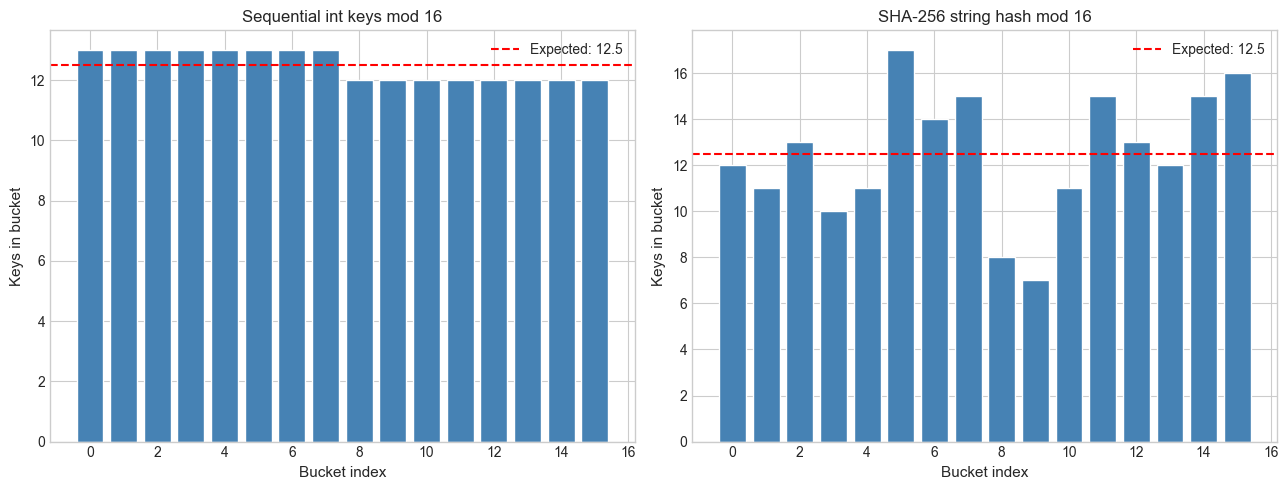

Sequential integers already distribute perfectly — they're uniform by construction.
Real-world keys (strings, IDs) require a proper hash function before the mod.


In [1]:
# --- Visualization: Hash table load distribution ---
import numpy as np
import matplotlib.pyplot as plt
import hashlib

plt.style.use('seaborn-v0_8-whitegrid')

TABLE_SIZE = 16  # <-- try prime (17) vs composite (16) sizes
N_KEYS = 200

# Generate keys: sequential integers vs random strings
seq_keys = list(range(N_KEYS))
str_keys = [f"user_{i}" for i in range(N_KEYS)]

def hash_int(k, size):
    """Naive hash: identity mod size."""
    return k % size

def hash_string(s, size):
    """Better hash: use SHA-256 truncated to int."""
    h = int(hashlib.sha256(s.encode()).hexdigest(), 16)
    return h % size

seq_buckets = np.zeros(TABLE_SIZE, dtype=int)
str_buckets = np.zeros(TABLE_SIZE, dtype=int)

for k in seq_keys:
    seq_buckets[hash_int(k, TABLE_SIZE)] += 1
for s in str_keys:
    str_buckets[hash_string(s, TABLE_SIZE)] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

expected = N_KEYS / TABLE_SIZE

for ax, buckets, title in zip(axes,
    [seq_buckets, str_buckets],
    [f'Sequential int keys mod {TABLE_SIZE}',
     f'SHA-256 string hash mod {TABLE_SIZE}']):
    ax.bar(range(TABLE_SIZE), buckets, color='steelblue', edgecolor='white')
    ax.axhline(expected, color='red', linestyle='--', label=f'Expected: {expected:.1f}')
    ax.set_xlabel('Bucket index', fontsize=11)
    ax.set_ylabel('Keys in bucket', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()
print("Sequential integers already distribute perfectly — they're uniform by construction.")
print("Real-world keys (strings, IDs) require a proper hash function before the mod.")

---

## 4. Mathematical Formulation

### RSA Algorithm

**Key generation:**
1. Choose two distinct primes `p` and `q`
2. Compute `n = p · q` (the modulus)
3. Compute `φ(n) = (p−1)(q−1)`
4. Choose public exponent `e` with `1 < e < φ(n)` and `gcd(e, φ(n)) = 1`
5. Compute private exponent `d` such that `e · d ≡ 1 (mod φ(n))`
   - Public key: `(e, n)`, Private key: `(d, n)`

**Encryption** (given message `m < n`):
```
c = m^e mod n
```

**Decryption** (given ciphertext `c`):
```
m = c^d mod n
```

**Why does decryption recover m?**  
```
c^d = (m^e)^d = m^(ed) mod n
```
Since `ed ≡ 1 (mod φ(n))`, we have `ed = 1 + k·φ(n)` for some integer k. By Euler's theorem:
```
m^(ed) = m^(1 + k·φ(n)) = m · (m^φ(n))^k ≡ m · 1^k = m (mod n)
```
This is the core mathematical guarantee of RSA.

### Ring Buffer

A ring buffer of capacity `C` maintains head pointer `h` and tail pointer `t`, both advancing modulo `C`:
```
h = (h + 1) % C   (after each read)
t = (t + 1) % C   (after each write)
```
Buffer is empty when `h == t`. Full when `(t + 1) % C == h`.

---

## 5. Python Implementation

In [2]:
# --- Implementation 1: Minimal RSA from scratch ---
import math
import random

def extended_gcd(a, b):
    if b == 0:
        return a, 1, 0
    g, x1, y1 = extended_gcd(b, a % b)
    return g, y1, x1 - (a // b) * y1

def mod_inverse(a, n):
    g, x, _ = extended_gcd(a % n, n)
    if g != 1:
        raise ValueError(f"Inverse of {a} mod {n} does not exist")
    return x % n

def rsa_keygen(p, q, e=None):
    """
    Generate RSA key pair from primes p and q.

    Args:
        p, q: distinct primes
        e: public exponent (default: 65537)

    Returns:
        (public_key, private_key) where each is (exponent, modulus)
    """
    n = p * q
    phi_n = (p - 1) * (q - 1)
    if e is None:
        e = 65537  # standard choice: prime, has efficient binary repr
    assert 1 < e < phi_n
    assert math.gcd(e, phi_n) == 1, f"e={e} must be coprime to φ(n)={phi_n}"
    d = mod_inverse(e, phi_n)
    return (e, n), (d, n)

def rsa_encrypt(m, public_key):
    """
    Encrypt message integer m with public key (e, n).
    Requires 0 <= m < n.
    """
    e, n = public_key
    assert 0 <= m < n, "Message must be in [0, n-1]"
    return pow(m, e, n)  # Python's built-in fast modular exponentiation

def rsa_decrypt(c, private_key):
    """
    Decrypt ciphertext c with private key (d, n).
    """
    d, n = private_key
    return pow(c, d, n)


# Demo with small primes (educational — real RSA uses 1024+ bit primes)
p, q = 61, 53
pub, priv = rsa_keygen(p, q, e=17)

print(f"Primes: p={p}, q={q}")
print(f"n = {pub[1]},  φ(n) = {(p-1)*(q-1)}")
print(f"Public key:  (e={pub[0]}, n={pub[1]})")
print(f"Private key: (d={priv[0]}, n={priv[1]})")

message = 42
ciphertext = rsa_encrypt(message, pub)
recovered  = rsa_decrypt(ciphertext, priv)

print(f"\nMessage:    {message}")
print(f"Ciphertext: {ciphertext}")
print(f"Decrypted:  {recovered}")
print(f"Correct:    {message == recovered}")

Primes: p=61, q=53
n = 3233,  φ(n) = 3120
Public key:  (e=17, n=3233)
Private key: (d=2753, n=3233)

Message:    42
Ciphertext: 2557
Decrypted:  42
Correct:    True


In [3]:
# --- Implementation 2: Ring Buffer ---

class RingBuffer:
    """
    Fixed-capacity ring buffer (circular queue).
    Uses modular indexing to wrap head and tail pointers.

    Args:
        capacity: maximum number of elements
    """
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = [None] * capacity
        self.head = 0   # next read position
        self.tail = 0   # next write position
        self.size = 0

    def enqueue(self, value):
        """Write value. Overwrites oldest if full."""
        self.buffer[self.tail] = value
        self.tail = (self.tail + 1) % self.capacity  # mod wrap!
        if self.size == self.capacity:
            # Overwrite mode: advance head past overwritten slot
            self.head = (self.head + 1) % self.capacity
        else:
            self.size += 1

    def dequeue(self):
        """Read and remove oldest value. Raises if empty."""
        if self.size == 0:
            raise IndexError("Buffer is empty")
        value = self.buffer[self.head]
        self.head = (self.head + 1) % self.capacity  # mod wrap!
        self.size -= 1
        return value

    def to_list(self):
        """Return contents in FIFO order."""
        return [self.buffer[(self.head + i) % self.capacity]
                for i in range(self.size)]


# Demo: streaming sensor data with sliding window
rb = RingBuffer(capacity=5)
sensor_readings = [10, 20, 30, 40, 50, 60, 70]  # more data than buffer size

print("Streaming into ring buffer (capacity=5):")
for val in sensor_readings:
    rb.enqueue(val)
    print(f"  Wrote {val:3d} → buffer: {rb.to_list()}")

print(f"\nFinal buffer (last 5 readings): {rb.to_list()}")

Streaming into ring buffer (capacity=5):
  Wrote  10 → buffer: [10]
  Wrote  20 → buffer: [10, 20]
  Wrote  30 → buffer: [10, 20, 30]
  Wrote  40 → buffer: [10, 20, 30, 40]
  Wrote  50 → buffer: [10, 20, 30, 40, 50]
  Wrote  60 → buffer: [20, 30, 40, 50, 60]
  Wrote  70 → buffer: [30, 40, 50, 60, 70]

Final buffer (last 5 readings): [30, 40, 50, 60, 70]


---

## 6. Experiments

In [4]:
# --- Experiment 1: RSA correctness across all valid messages ---
# Hypothesis: RSA decryption recovers every message m in [0, n-1].
# Try changing: the primes p and q.

p, q = 61, 53   # <-- modify with other small primes
e = 17
pub, priv = rsa_keygen(p, q, e)
n = pub[1]

failures = []
for m in range(n):
    c = rsa_encrypt(m, pub)
    m2 = rsa_decrypt(c, priv)
    if m2 != m:
        failures.append(m)

print(f"n = {n}, tested all {n} messages")
print(f"Failures: {failures if failures else 'none — RSA is correct for all m'}")

# Note: for m = 0, 1, p, q, n-1: these are edge cases worth checking
edge_cases = [0, 1, p, q, n-1]
print("\nEdge cases:")
for m in edge_cases:
    if 0 <= m < n:
        c = rsa_encrypt(m, pub)
        m2 = rsa_decrypt(c, priv)
        print(f"  m={m}: encrypt={c}, decrypt={m2}, ok={m==m2}")

n = 3233, tested all 3233 messages
Failures: none — RSA is correct for all m

Edge cases:
  m=0: encrypt=0, decrypt=0, ok=True
  m=1: encrypt=1, decrypt=1, ok=True
  m=61: encrypt=610, decrypt=61, ok=True
  m=53: encrypt=1802, decrypt=53, ok=True
  m=3232: encrypt=3232, decrypt=3232, ok=True


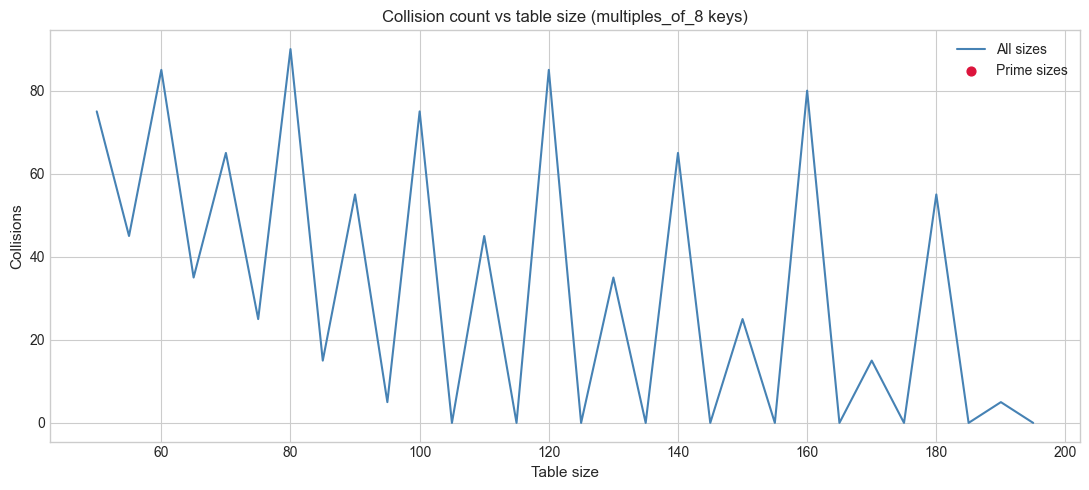

In [5]:
# --- Experiment 2: Hash table collision rate vs table size ---
# Hypothesis: using a prime table size reduces collisions compared to a power of 2,
#             especially for keys that are multiples of common factors.
# Try changing: KEY_PATTERN and sizes.

import matplotlib.pyplot as plt
import hashlib

N_KEYS = 100
KEY_PATTERN = 'multiples_of_8'  # <-- try 'random', 'sequential', 'multiples_of_8'

if KEY_PATTERN == 'random':
    import random
    keys = [random.randint(0, 10000) for _ in range(N_KEYS)]
elif KEY_PATTERN == 'sequential':
    keys = list(range(N_KEYS))
elif KEY_PATTERN == 'multiples_of_8':
    keys = [8 * i for i in range(N_KEYS)]

sizes = list(range(50, 200, 5))
collision_counts = []

for size in sizes:
    buckets = {}
    collisions = 0
    for k in keys:
        slot = k % size
        if slot in buckets:
            collisions += 1
        buckets[slot] = k
    collision_counts.append(collisions)

# Identify prime sizes in the range
def is_prime(n):
    if n < 2: return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0: return False
    return True

prime_sizes = [s for s in sizes if is_prime(s)]
prime_collisions = [collision_counts[sizes.index(s)] for s in prime_sizes]

plt.figure(figsize=(11, 5))
plt.plot(sizes, collision_counts, 'steelblue', linewidth=1.5, label='All sizes')
plt.scatter(prime_sizes, prime_collisions, color='crimson', s=40, zorder=4, label='Prime sizes')
plt.xlabel('Table size', fontsize=11)
plt.ylabel('Collisions', fontsize=11)
plt.title(f'Collision count vs table size ({KEY_PATTERN} keys)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

---

## 7. Exercises

**Easy 1.** What day of the week is January 1, 2030? Use Zeller's formula (look it up) — it is entirely modular arithmetic. Verify with Python's `datetime` module.  
*(Expected: a day name)*

**Easy 2.** Implement a `circular_array_max(arr, start, window)` function that computes the max of `window` elements starting at `start`, wrapping around if needed, using only modular indexing.  

**Medium 1.** Break toy RSA: given public key (e=17, n=3233), factor n, recover φ(n), compute d, and decrypt the ciphertext c=2790. Show each step.  
*(Hint: n=3233=61×53 — but write code that finds the factors by trial division)*

**Medium 2.** Implement a simple polynomial rolling hash function `poly_hash(s, p=31, m=10^9+7)` that computes `sum(s[i] * p^i) mod m`. Verify that a single character change always produces a different hash for strings up to length 20.

**Hard.** Implement RSA with padding: real RSA never encrypts raw numbers but pads the message to make the scheme semantically secure (OAEP). Implement a simplified version: before encrypting, XOR the message bytes with a random mask derived from the hash of a random seed; include the seed in the ciphertext. Show that encrypting the same message twice gives different ciphertexts.

---

## 8. Mini Project — Polynomial Rolling Hash for Substring Search

**Problem:** The Rabin-Karp algorithm finds all occurrences of a pattern in a text in O(n+m) expected time using a rolling hash. The rolling hash updates in O(1) by removing the leftmost character's contribution and adding the new rightmost character — all via modular arithmetic.

**Task:** Implement Rabin-Karp substring search from scratch. Measure its speed against naive O(nm) search on a large text.

In [ ]:
# --- Mini Project: Rabin-Karp Substring Search ---
# Problem: Find all occurrences of a pattern in a text using rolling hash.
# Dataset: generated text string + pattern to search.
# Task: implement the rolling hash update, complete the search, benchmark.

import time

PRIME_BASE = 31          # polynomial base
MOD = (1 << 61) - 1     # Mersenne prime — large, efficient mod

def poly_hash(s, base=PRIME_BASE, mod=MOD):
    """
    Compute polynomial hash of string s.
    hash = sum(ord(s[i]) * base^i) mod mod
    """
    h = 0
    power = 1
    for ch in s:
        h = (h + ord(ch) * power) % mod
        power = (power * base) % mod
    return h


def rabin_karp(text, pattern, base=PRIME_BASE, mod=MOD):
    """
    Find all start indices where pattern occurs in text.
    Uses rolling hash: O(n + m) expected time.

    Args:
        text: haystack string
        pattern: needle string

    Returns:
        list of start indices
    """
    n, m = len(text), len(pattern)
    if m > n:
        return []

    pattern_hash = poly_hash(pattern, base, mod)

    # Precompute base^m mod mod (the leading power to subtract)
    leading_power = pow(base, m, mod)

    # TODO: compute initial window hash for text[0:m]
    window_hash = poly_hash(text[:m], base, mod)

    matches = []
    if window_hash == pattern_hash and text[:m] == pattern:
        matches.append(0)

    for i in range(1, n - m + 1):
        # TODO: update window_hash by:
        #   1. Remove contribution of text[i-1] (subtract ord(text[i-1]) * base^0, then divide by base)
        #   2. This is equivalent to: h_new = (h_old - ord(text[i-1])) * inv(base) mod mod
        #   OR equivalently (simpler):
        #   window_hash = (window_hash - ord(text[i-1])) / base + ord(text[i+m-1]) * base^(m-1)
        # Here we use the additive form with the leading_power trick:
        window_hash = (window_hash - ord(text[i - 1])) % mod
        window_hash = (window_hash * pow(base, mod - 2, mod)) % mod  # multiply by base^(-1)
        window_hash = (window_hash + ord(text[i + m - 1]) * pow(base, m - 1, mod)) % mod

        if window_hash == pattern_hash:
            if text[i:i+m] == pattern:  # verify to handle hash collisions
                matches.append(i)

    return matches


def naive_search(text, pattern):
    """O(n*m) naive substring search for comparison."""
    n, m = len(text), len(pattern)
    return [i for i in range(n - m + 1) if text[i:i+m] == pattern]


# Generate test data
import random, string
random.seed(42)
TEXT = ''.join(random.choices('ACGT', k=100_000))  # DNA-like sequence
PATTERN = 'ACGTACGT'

# Benchmark
t0 = time.perf_counter()
rk_matches = rabin_karp(TEXT, PATTERN)
t1 = time.perf_counter()
naive_matches = naive_search(TEXT, PATTERN)
t2 = time.perf_counter()

print(f"Text length: {len(TEXT)}, Pattern: '{PATTERN}'")
print(f"Matches found: {len(rk_matches)}")
print(f"Results agree: {rk_matches == naive_matches}")
print(f"\nRabin-Karp: {(t1-t0)*1000:.2f} ms")
print(f"Naive:      {(t2-t1)*1000:.2f} ms")
print(f"Speedup:    {(t2-t1)/(t1-t0):.1f}x")

---

## 9. Chapter Summary & Connections

**What we covered:**
- Hash tables use `hash(key) % size`; prime table sizes reduce collision clustering
- RSA relies entirely on modular exponentiation; correctness follows from Euler's theorem
- Ring buffers implement infinite-tape semantics with finite memory via mod indexing
- Rolling hashes enable O(n) substring search by updating hash in O(1) using mod arithmetic
- All of these are the same mathematical operation applied to different problems

**Backward connection:**  
RSA decryption correctness relies on Euler's theorem and modular inverses *(ch031–ch032)*. Without those, the algorithm is a magic trick without an explanation.

**Forward connections:**
- Polynomial hashing *(this chapter)* reappears in **ch246 — Random Variables**, where we analyze the expected number of collisions formally
- The ring buffer pattern reappears in **ch086 — Discrete Dynamical Systems** as a computational structure for storing system history
- RSA's reliance on large prime products connects directly to **ch028 — Prime Numbers** and sets the stage for the full cryptographic treatment in number theory courses beyond this book

**Going deeper:** Study the *birthday paradox* (ch243) to understand why hash collision probability grows quadratically in load factor, and why prime table sizes matter less than you'd expect with a good hash function.